<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# Liga Data Science
## Prof. Eduardo Pécora

# Métodos de Classificação
Tempo estimado: **90** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Compreender a natureza dos métodos de classificação (coisas em caixinhas)
* Usar a árvore de classificação para fazer uma análise descritiva.

---


Case de distribuição de e-commerce

# **Verifica a versão do Python e importa as bibliotecas básicas**

In [106]:
# check Python version
!python -V

import pandas as pd # download library to read data into dataframe
#pd.set_option('display.max_columns', None)
import numpy as np # import numpy library
import matplotlib.pyplot as plt # plots
import collections
import random # library for random number generation

from google.colab import files
import io
#import csv


Python 3.12.13


#Importar Arquivo de dados

Inclua um CSV com os dados a serem analisados
 * Incluindo cabeçalho
 * Separação de campos delimitado por *,*
 * Separação de linha usando *nova linha*

 O arquivo tem mais de 6000 registros, pode levar alguns segundos.

In [107]:
csvString = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/Distribution_12k.csv"

starsData = pd.read_csv(csvString)

print("Data read into dataframe!") # takes about 30 seconds
starsData.head()

Data read into dataframe!


,Stars,Product,Origin,CD_name,Dest,DistanceTravelled_Fac_CD,TruckType,DriverF_CD,DaysStocked,FloorCD,DistanceTravelled_CD_Client,TruckType2,DriverCD_C,RoutDeliveryOrder
0,4.0,P6,F4,CD2,C203,162,SemiTrailler,D05,37,2,59.7,CityDeliveryTruck,D2_2,2
1,1.0,P2,F3,CD2,C202,162,SemiTrailler,D06,5,0,94.2,MiniVan,D2_4,3
2,5.0,P6,F3,CD2,C202,162,SemiTrailler,D04,27,0,30.9,Van,D2_7,1
3,2.0,P9,F3,CD2,C202,162,SemiTrailler,D03,14,0,89.7,Van,D2_7,3
4,5.0,P9,F2,CD3,C305,58,Truck,D03,30,1,171.7,Van,D3_2,6


# Padronização do DataTable


## Renomear a primeira coluna para "stars"

Para se adequar ao código

In [108]:
# fix name of the column displaying the Stars
column_names = starsData.columns.values
print(starsData.columns.values)
column_names[0] = "stars"
starsData.columns = column_names
print(column_names)


['Stars' 'Product' 'Origin' 'CD_name' 'Dest' 'DistanceTravelled_Fac_CD'
 'TruckType' 'DriverF_CD' 'DaysStocked' 'FloorCD'
 'DistanceTravelled_CD_Client' 'TruckType2' 'DriverCD_C'
 'RoutDeliveryOrder']
['stars' 'Product' 'Origin' 'CD_name' 'Dest' 'DistanceTravelled_Fac_CD'
 'TruckType' 'DriverF_CD' 'DaysStocked' 'FloorCD'
 'DistanceTravelled_CD_Client' 'TruckType2' 'DriverCD_C'
 'RoutDeliveryOrder']


# Verificando os dados

## Em um contexto real, deveríamos verificar cada coluna minuciosamente procurando por valores fora dos padrões. Mas aqui vamos "verificar" somente a coluna "stars"

### Exemplos mais comuns de valores fora dos padrões são:

* Valores numéricos fora do intervalo, por exemplo quantidades de estrelas igual a 15, quando devia ser de 1 a 5.
* Texto no local de valores numéricos
* Valores "nan" Not a Number
* Para valores de categorias, no nosso exemplo os produtos são P1, P2, P3; Caso apareca um "Produto 1" precisa ser uniformizado


3.028867985728187
[(1.0, 2303), (2.0, 2383), (3.0, 2769), (4.0, 2469), (5.0, 2357), (6.0, 48), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (nan, 1), (7.0, 1), (9.0, 1), (11.0, 1)]


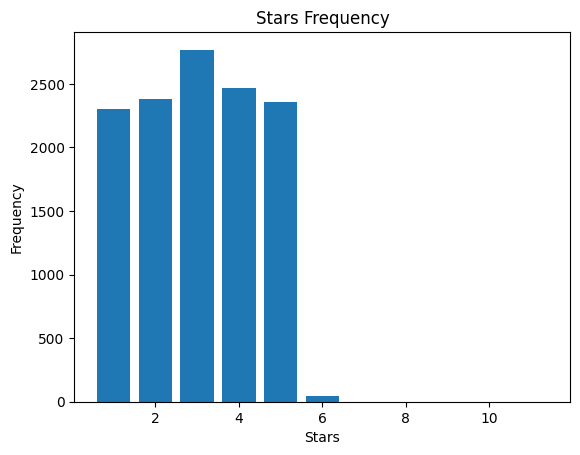

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 7.0, 9.0, 11.0]


In [109]:
starsData["stars"].value_counts() # frequency table

print(starsData["stars"].mean())

c = collections.Counter(starsData["stars"])
c = sorted(c.items())
print(c)

stars_num = [i[0] for i in c]
freq = [i[1] for i in c]

f, ax = plt.subplots()

plt.bar(stars_num, freq)

plt.title("Stars Frequency")
plt.xlabel("Stars")
plt.ylabel("Frequency")
#ax.set_xticks(range(1, 8))

plt.show()

print(stars_num)

# Existem dados fora do intevalo de estrelas [1,5] , alguns valores são 6 outros são NAN

##Limpar dados de estrelas fora do intervalo [1,5], excluindo os registros

3.0157967592215615
[(1.0, 2303), (2.0, 2383), (3.0, 2769), (4.0, 2469), (5.0, 2357)]


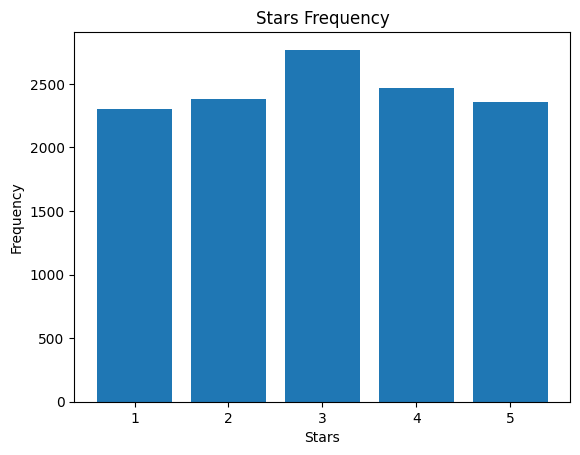

[1.0, 2.0, 3.0, 4.0, 5.0]


In [110]:
starsData = starsData[starsData["stars"] <= 5]
starsData = starsData[starsData["stars"] >= 1]

starsData = starsData[starsData["FloorCD"] <= 4] # aproveitei e padronizei outros dados numéricos também
starsData = starsData[starsData["FloorCD"] >= 0]

starsData = starsData[starsData["RoutDeliveryOrder"] <= 6]
starsData = starsData[starsData["RoutDeliveryOrder"] >= 1]

starsData["stars"].value_counts() # frequency table

print(starsData["stars"].mean())

c = collections.Counter(starsData["stars"])
c = sorted(c.items())
print(c)

stars_num = [i[0] for i in c]
freq = [i[1] for i in c]

f, ax = plt.subplots()

plt.bar(stars_num, freq)

plt.title("Stars Frequency")
plt.xlabel("Stars")
plt.ylabel("Frequency")

plt.show()

print(stars_num)

starsData = starsData.reset_index(drop=True) # É importante refazer o indice do dataFrame, apeos excluir linhas, pois pode gerar problema no SciKit Learn


#Outras inconsistências nos dados

### Note a coluna Driver_F_CD, ela só tem os valores "D01" ... "D06" mas não sabemos se o motorista D01 pode trabalhar no CD1, CD2 ou CD3 ? Isso não te parece no mínimo esquisito ?

### Fica como Lição de casa você pensar em uma alternativa


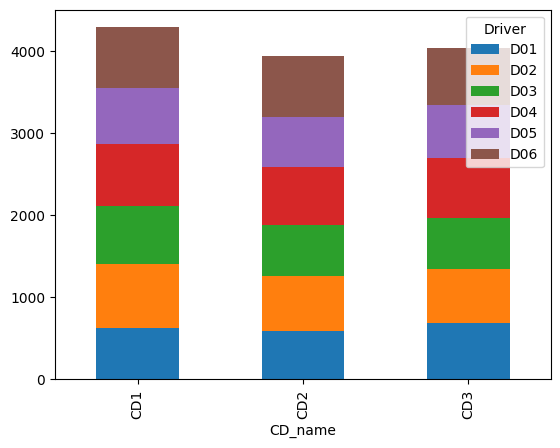

DriverF_CD  D01  D02  D03  D04  D05  D06
CD_name                                 
CD1         632  776  704  752  684  744
CD2         588  676  620  700  620  744
CD3         689  660  624  720  648  700


In [111]:
ct = pd.crosstab(index=starsData['CD_name'], columns=starsData['DriverF_CD'])

ct.plot.bar(stacked=True)
plt.legend(title='Driver')

plt.show()

print(ct)


# Começando a análise

## Importar as bibliotecas:
* SKLEARN
* graphviz
* matplotlib


In [112]:
# import decision trees scikit-learn libraries
%matplotlib inline
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix # Não usaremos essas métricas neste exemplo

import matplotlib.pyplot as plt

#!conda install python-graphviz --yes
import graphviz

from sklearn.tree import export_graphviz

import itertools

# Separar o dataFrame em variáveis dependentes e independentes

In [113]:
# split the DataFrame
stars = starsData["stars"] # Só a coluna "stars"
stars_class = stars[:]
variables = starsData.iloc[:,1:] # Todas as outras colunas com excessão da "stars"

# Deixe essa parte do código comentado poor enquanto

#stars_class.loc[stars <= 2] = "bad"
#stars_class.loc[stars == 3] = "average"
#stars_class.loc[stars >= 4] = "good"

stars_class.head()

,stars
0,4.0
1,1.0
2,5.0
3,2.0
4,5.0


In [114]:
variables.head()

,Product,Origin,CD_name,Dest,DistanceTravelled_Fac_CD,TruckType,DriverF_CD,DaysStocked,FloorCD,DistanceTravelled_CD_Client,TruckType2,DriverCD_C,RoutDeliveryOrder
0,P6,F4,CD2,C203,162,SemiTrailler,D05,37,2,59.7,CityDeliveryTruck,D2_2,2
1,P2,F3,CD2,C202,162,SemiTrailler,D06,5,0,94.2,MiniVan,D2_4,3
2,P6,F3,CD2,C202,162,SemiTrailler,D04,27,0,30.9,Van,D2_7,1
3,P9,F3,CD2,C202,162,SemiTrailler,D03,14,0,89.7,Van,D2_7,3
4,P9,F2,CD3,C305,58,Truck,D03,30,1,171.7,Van,D3_2,6


# Adequação das variáveis categóricas em colunas binárias - OneHotEncoder




In [115]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(variables[['Product']])
# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out(['Product']))
# Concatene o DataFrame dummy com os outros dados
variables = pd.concat([variables.drop('Product', axis=1), dummy_df], axis=1)

#variables = variables.drop(['Origin', 'CD_name', 'Dest', 'TruckType', 'DriverF_CD', 'TruckType2'])

var1 = variables.copy()

var1 = var1.drop(['Origin','CD_name', 'Dest', 'TruckType', 'DriverF_CD', 'TruckType2','DriverCD_C'], axis = 1)

var1.head()

,DistanceTravelled_Fac_CD,DaysStocked,FloorCD,DistanceTravelled_CD_Client,RoutDeliveryOrder,Product_P1,Product_P10,Product_P11,Product_P12,Product_P13,Product_P14,Product_P15,Product_P2,Product_P3,Product_P4,Product_P5,Product_P6,Product_P7,Product_P8,Product_P9
0,162,37,2,59.7,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,162,5,0,94.2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,162,27,0,30.9,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,162,14,0,89.7,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,58,30,1,171.7,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## DecisionTreeClassifier e os seus Parâmetros

O algoritimo do DecisionTreeClassifier tem a tendência natural de fazer um OVERFITING, para ajustar isso modificamos os parâmetros:

* max_depth : Profundidade máxima da árvore
* min_samples_split : quantidade mínima de amostras para se dividir um nó
* min_samples_leaf : Quantidade mínima de amostras em um nó folha (nó da base da árvore)

In [116]:
delivery_tree = tree.DecisionTreeClassifier(max_depth = 4, min_samples_split = 2, min_samples_leaf = 1)
delivery_tree.fit(var1, stars_class)

print("Decision tree model saved to delivery_tree!")
print(delivery_tree)
print(var1.columns.values)

Decision tree model saved to delivery_tree!
DecisionTreeClassifier(max_depth=4)
['DistanceTravelled_Fac_CD' 'DaysStocked' 'FloorCD'
 'DistanceTravelled_CD_Client' 'RoutDeliveryOrder' 'Product_P1'
 'Product_P10' 'Product_P11' 'Product_P12' 'Product_P13' 'Product_P14'
 'Product_P15' 'Product_P2' 'Product_P3' 'Product_P4' 'Product_P5'
 'Product_P6' 'Product_P7' 'Product_P8' 'Product_P9']


# Resultados em formato gráfico são sempre melhores ;)

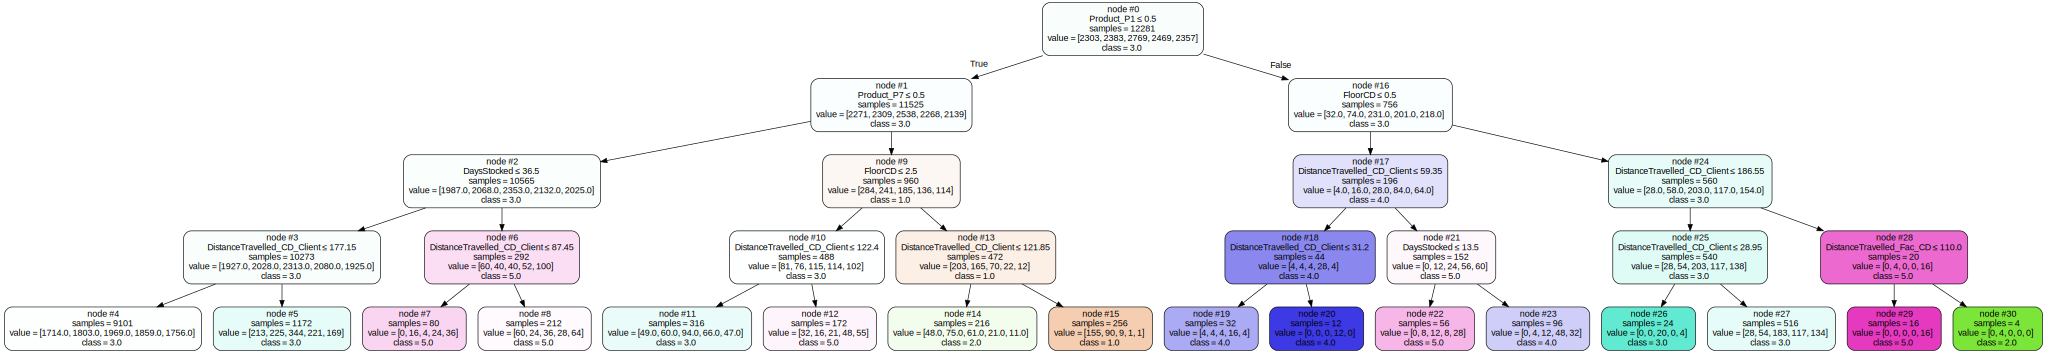

In [117]:
export_graphviz(delivery_tree,
                feature_names=list(var1.columns.values),
                out_file="delivery_tree.dot",
                class_names=np.unique(stars_class.astype(str)),
                filled=True,
                rounded=True,
                node_ids=True,
                special_characters=True,
                impurity=False,
                label="all",
                leaves_parallel = False)

with open("delivery_tree.dot") as delivery_tree_image:
    delivery_tree_graph = delivery_tree_image.read()
graphviz.Source(delivery_tree_graph)

# *Brinque um pouco com os parâmetros modificando-os para ver o que acontece!*


### Obrigado por concluir o SUPER CASE!

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  
## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

<a href="https://www.linkedin.com/in/rafael-fix/" target="_blank">Rafael Fix</a>


## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Documentação               |
| 04-04-2023       | 1.1     | Rafael Fix     | Adequações               |
| 04-04-2026       | 1.2     | Eduardo Pecora    | Estrutura de Aula               |

<hr>

## <h3 align="center"> (c) LDS / UFPR 2026. All rights reserved. <h3/>

